## 1. Разведочный анализ данных (EDA) и предобработка
Цель: Оценка качества сырых данных, профилирование аудитории и очистка датасета от аномалий.

Проверка типов данных и обработка пропущенных значений.

Удаление статистических выбросов по возрасту с использованием метода межквартильного размаха (IQR).

Визуализация распределения очищенной базы пользователей.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
users_info = pd.read_csv('users_info.csv')
users_info.head()

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
3,1003,Москва,NaN,NaN
4,1004,Екатеринбург,60.0,male


In [4]:
users_info.shape

(1000, 4)

In [5]:
users_info.dtypes



id_user      int64
city        object
age        float64
gender      object
dtype: object

In [6]:
ui=users_info 

In [7]:
ui_cl=ui.dropna()

In [8]:
ui.count()

id_user    1000
city       1000
age         912
gender      911
dtype: int64

In [9]:
ui.isnull().sum()

id_user     0
city        0
age        88
gender     89
dtype: int64

In [10]:
ui.isnull().sum()/ui.count()

id_user    0.000000
city       0.000000
age        0.096491
gender     0.097695
dtype: float64

In [11]:
q1=np.percentile(ui_cl['age'],25)
print(q1)
q3=np.percentile(ui_cl['age'],75)
print(q3)
IQR=q3-q1
lower_bound=q1-1.5*IQR
upper_bound=q3+1.5*IQR
print(lower_bound)
print(upper_bound)

28.0
51.0
-6.5
85.5


In [12]:
ui_cl=ui_cl.loc[ui_cl['age']<upper_bound]
ui_cl.head()

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
4,1004,Екатеринбург,60.0,male
5,1005,СПб,35.0,female


<Axes: xlabel='age', ylabel='Count'>

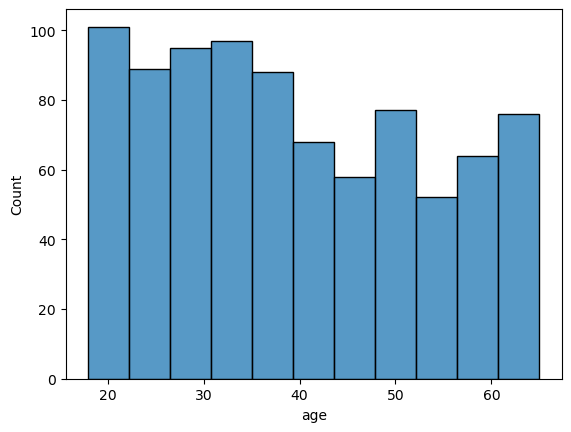

In [13]:
sns.histplot(ui_cl['age'])

## 2. Демографический анализ аудитории
Цель: Выявить региональные особенности в распределении пользователей.

Агрегация данных и расчет доли женщин в разрезе городов.

Визуализация отклонений для поиска аномальных регионов.

In [14]:
pivot_table=ui_cl.pivot_table(index ='city',\
                              columns='gender',\
                              values='id_user',\
                              aggfunc= 'count',\
                              fill_value = 0 )


In [15]:
pivot_table.columns.name= None 
pl=pivot_table.head().reset_index()
pl.head()

,city,female,male
0,Екатеринбург,55,78
1,Казань,53,77
2,Москва,220,105
3,СПб,123,154


In [16]:
pl['allperson']=pl['female']+pl['male']
pl['part_ofwomen']= pl['female']/pl['allperson']
pl['part_ofwomen']=pl['part_ofwomen'].round(2)
pl.head()

,city,female,male,allperson,part_ofwomen
0,Екатеринбург,55,78,133,0.41
1,Казань,53,77,130,0.41
2,Москва,220,105,325,0.68
3,СПб,123,154,277,0.44


<Axes: xlabel='city'>

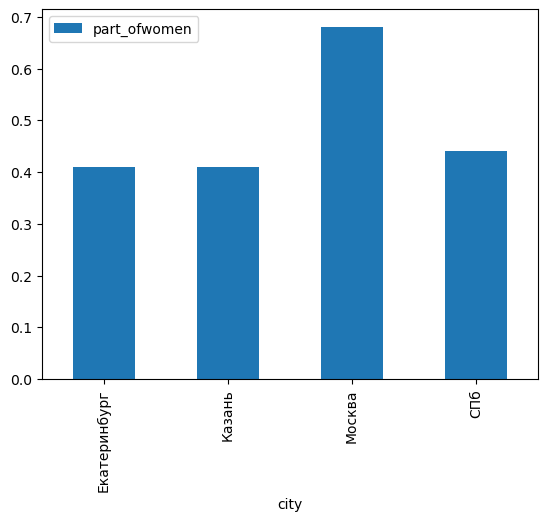

In [17]:
pl.plot(kind='bar',x = 'city',y='part_ofwomen')

## 3. Сегментация пользователей по уровню активности
Цель: Кластеризация клиентской базы для последующих маркетинговых активностей.

Расчет средней частоты тренировок.

Разделение пользователей на 3 когорты (низкая, средняя, высокая активность) на основе перцентилей.

In [19]:
pl2=pay_mon.groupby('id_user').agg(avg_tern=('cnt_total','mean')).reset_index()
pl2.head(10)

,id_user,avg_tern
0,1000,3.666667
1,1001,11.727273
2,1002,11.636364
3,1003,5.166667
4,1004,2.000000
5,1005,3.500000
6,1006,9.750000
7,1007,1.250000
8,1008,5.500000
9,1009,2.250000


In [22]:
bins=[0,6,10,float('inf')]
labels=['низкий', 'средний', 'высокий']
pl2['teg']=pd.cut(pl2['avg_tern'], bins=bins, labels=labels, right=True)
pl2.head(10)


,id_user,avg_tern,teg
0,1000,3.666667,низкий
1,1001,11.727273,высокий
2,1002,11.636364,высокий
3,1003,5.166667,низкий
4,1004,2.000000,низкий
5,1005,3.500000,низкий
6,1006,9.750000,средний
7,1007,1.250000,низкий
8,1008,5.500000,низкий
9,1009,2.250000,низкий


In [21]:
pl2.groupby('teg').count()[['id_user']]

C:\Users\user\AppData\Local\Temp\ipykernel_13548\3418212770.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pl2.groupby('teg').count()[['id_user']]


,id_user
teg,
низкий,535
средний,280
высокий,154
